# 104 Xenium Inference & Visualization (Tutorial)

This notebook covers:
1) Spot-level prediction (True vs Pred)
2) Super-resolution prediction (dense map)

Outputs will be saved to `results/st_superres/xenium_XEN2/`.
Recommended: run in **scellst_bench** environment with GPU enabled.


In [1]:
from __future__ import annotations

from pathlib import Path
import os
import json
import time

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

from st_pipeline.constants import KEYS
from st_pipeline.superres.feature_cache import ensure_feature_cache, load_cache_slide, normalize_slide
from st_pipeline.data.gene_vocab import load_gene_vocab, map_genes_to_vocab
from st_pipeline.data.collate import mil_collate
from st_pipeline.model.morpho_cellfm_mil import MorphoCellfmMIL


C:\ProgramData\anaconda3\envs\scellst_bench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Configuration

Centralize all parameters here.
- `RUN_SPOT_PRED`: whether to run spot prediction
- `RUN_SUPERRES`: whether to run super-resolution prediction
- `SUPERRES_GENES`: list of genes for super-res (None = all genes)


In [2]:
# ----------------------------
# 0) Config
# ----------------------------
ROOT = Path(os.environ.get("MORPHO_VC_ROOT", r"e:\Morpho-VC")).resolve()

CKPT_DIR = ROOT / "checkpoints" / "st_superres" / "xenium_cellfm"
RESULT_DIR = ROOT / "results" / "st_superres" / "xenium_cellfm_1" / "xenium_XEN2"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

gene_vocab_path = ROOT / "assets" / "cellfm" / "expand_gene_info.csv"
cellfm_checkpoint = ROOT / "checkpoints" / "CellFM" / "CellFM_80M_weight.pt"

TEST_ID = "XEN2"

# Cache params
force_recompute = False
max_dim = 16000

# Inference params
batch_size = 50
num_workers = 0  # Windows: 0 is usually more stable
use_amp = True
gene_chunk_size = 512
heartbeat_batches = 2  # used only if tqdm is unavailable

# Execution switches
RUN_SPOT_PRED = True
RUN_SUPERRES = True
SUPERRES_GENES = ["ERBB2"]  # None => all genes

# Cache reuse
REUSE_SPOT_CACHE = True
REUSE_SUPERRES_CACHE = True
BUILD_SPOT_FROM_SUPERRES = True
REUSE_SPOT_FROM_SUPERRES_CACHE = True

# Outputs & analysis
PLOT_TOP_GENES = 6
COMPUTE_GENE_GENE_CORR = True

print("TEST_ID:", TEST_ID)
print("RUN_SPOT_PRED:", RUN_SPOT_PRED, "| RUN_SUPERRES:", RUN_SUPERRES)
print("SUPERRES_GENES:", SUPERRES_GENES)
print("REUSE_SPOT_CACHE:", REUSE_SPOT_CACHE, "| REUSE_SUPERRES_CACHE:", REUSE_SUPERRES_CACHE)


TEST_ID: XEN2
RUN_SPOT_PRED: True | RUN_SUPERRES: True
SUPERRES_GENES: ['ERBB2']
REUSE_SPOT_CACHE: True | REUSE_SUPERRES_CACHE: True


## 1. Device & Cache Prep
We call `ensure_feature_cache` to generate HE thumbnails + HIPT embeddings (skips if already cached).


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass
else:
    print("WARNING: CUDA not available; inference will be slow.")

print("Ensuring feature cache...")
t0 = time.perf_counter()
ensure_feature_cache([TEST_ID], root=ROOT, force=force_recompute, device=device, max_dim=max_dim, use_tissue_seg=True)
print(f"Cache ready in {time.perf_counter() - t0:.1f}s")


Device: cuda
GPU: NVIDIA GeForce RTX 4090 D
Ensuring feature cache...
Cache ready in 0.0s


## 2. Load Genes & Dataset
Load common genes, map to CellFM vocab, then read cached embeddings/counts/coords.


In [4]:
common_genes = json.loads((CKPT_DIR / "common_genes.json").read_text())
print(f"Loaded common genes: {len(common_genes)}")

vocab = load_gene_vocab(gene_vocab_path)
kept_genes, gene_ids = map_genes_to_vocab(common_genes, vocab)


def get_disk_mask(radius):
    radius_ceil = int(np.ceil(radius))
    locs = np.meshgrid(
        np.arange(-radius_ceil, radius_ceil + 1),
        np.arange(-radius_ceil, radius_ceil + 1),
        indexing="ij",
    )
    locs = np.stack(locs, axis=-1)
    distsq = (locs ** 2).sum(-1)
    return distsq <= radius ** 2


GRID_FACTOR = 16


class SuperresSpotDataset(Dataset):
    def __init__(self, embs, cnts, locs_px, radius_px, gene_ids, grid_factor=GRID_FACTOR):
        super().__init__()
        self.embs = embs
        self.cnts = cnts
        self.gene_ids = gene_ids

        locs_px = np.asarray(locs_px, dtype=np.float32)
        self.locs_px = locs_px.copy()
        locs_grid = np.round(locs_px / float(grid_factor)).astype(np.int64)

        self.radius = float(radius_px) / float(grid_factor)
        self.mask = get_disk_mask(self.radius)
        self.mask_size = int(self.mask.sum())

        H, W = embs.shape[:2]
        r0, r1 = self._patch_offsets()
        valid = (
                (locs_grid[:, 0] + r0[0] >= 0) &
                (locs_grid[:, 0] + r0[1] <= H) &
                (locs_grid[:, 1] + r1[0] >= 0) &
                (locs_grid[:, 1] + r1[1] <= W)
        )
        finite_center = np.isfinite(embs[locs_grid[:, 0], locs_grid[:, 1]]).all(-1)
        valid &= finite_center

        self.keep_idx = np.where(valid)[0]
        self.locs = locs_grid[valid]
        self.locs_px = self.locs_px[valid]
        self.cnts = cnts[valid]

        sums = self.cnts.sum(axis=1)
        self.size_factors = (sums / (sums.mean() + 1e-8)).astype(np.float32)

    def _patch_offsets(self):
        shape = np.array(self.mask.shape)
        center = shape // 2
        r = np.stack([-center, shape - center], -1)
        return r[0], r[1]

    def __len__(self):
        return len(self.locs)

    def __getitem__(self, idx):
        i, j = self.locs[idx]
        r0, r1 = self._patch_offsets()
        patch = self.embs[i + r0[0]: i + r0[1], j + r1[0]: j + r1[1]]
        if self.mask.all():
            x = patch
        else:
            x = patch[self.mask]
        x = torch.from_numpy(x.astype(np.float32))
        y = torch.from_numpy(self.cnts[idx].astype(np.float32))
        size_factor = float(self.size_factors[idx])
        return {
            KEYS.X: x,
            KEYS.Y_BAG: y,
            KEYS.SIZE_FACTOR: size_factor,
            KEYS.GENE_IDS: self.gene_ids,
        }


print("Loading cached slide...")
t0 = time.perf_counter()
embs, cnts, locs, radius, gene_names, spot_ids = load_cache_slide(TEST_ID, root=ROOT, genes=kept_genes)
embs_norm, _, stats = normalize_slide(embs, cnts)
print(f"Loaded slide in {time.perf_counter() - t0:.1f}s | embs {embs.shape} cnts {cnts.shape} locs {locs.shape}")

test_ds = SuperresSpotDataset(embs_norm, cnts, locs, radius, gene_ids)
print(f"{TEST_ID} dataset size: {len(test_ds)} | mask_size: {test_ds.mask_size}")


XEN2 dataset size: 111890 | mask_size: 1


## 3. Load Model
Load the trained Morpho-CellFM checkpoint.


In [5]:
test_loader = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, collate_fn=mil_collate,
    pin_memory=(device.type == "cuda")
)

sample_batch = next(iter(test_loader))
input_dim = sample_batch[KEYS.X].shape[-1]

model = MorphoCellfmMIL(
    input_dim=input_dim,
    n_genes=len(kept_genes),
    cellfm_dim=1536,
    cellfm_layers=2,
    cellfm_heads=48,
    cellfm_checkpoint=str(cellfm_checkpoint),
    freeze_cellfm=True,
    use_mock=False,
    use_retention=True,
    vocab_size=len(vocab),
    dropout=0.1,
    aggregation="mean",
    dispersion="gene",
).to(device)

ckpt_path = CKPT_DIR / "best_model.pt"
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"Loaded checkpoint: {ckpt_path}")


Loaded checkpoint: E:\Morpho-VC\checkpoints\st_superres\xenium_cellfm\best_model.pt


## 4. Spot-level Prediction
Note: spot-level prediction is **not** super-resolution.


In [6]:
max_genes = len(kept_genes)
if gene_chunk_size >= max_genes:
    gene_chunks = [list(range(max_genes))]
else:
    gene_chunks = [list(range(i, min(i + gene_chunk_size, max_genes)))
                   for i in range(0, max_genes, gene_chunk_size)]
print(f"Gene chunks: {len(gene_chunks)} (chunk size {gene_chunk_size})")

pred_spot_path = RESULT_DIR / "pred_spot.npy"
true_spot_path = RESULT_DIR / "true_spot.npy"

if RUN_SPOT_PRED:
    if REUSE_SPOT_CACHE and pred_spot_path.exists() and true_spot_path.exists():
        pred_spot = np.load(pred_spot_path)
        true_spot = np.load(true_spot_path)
        print("Using cached spot predictions.")
    else:
        pred_spot = np.zeros((len(test_ds), max_genes), dtype=np.float32)
        true_spot = np.zeros((len(test_ds), max_genes), dtype=np.float32)
        offset = 0
        print("Starting spot-level prediction...")
        t0 = time.perf_counter()
        loader_iter = tqdm(test_loader, total=len(test_loader), desc="Spot Predict", ncols=100) if tqdm else test_loader
        with torch.inference_mode():
            for b_idx, batch in enumerate(loader_iter):
                for k in batch:
                    batch[k] = batch[k].to(device, non_blocking=True)

                bs = batch[KEYS.Y_BAG].shape[0]
                true_spot[offset:offset + bs] = batch[KEYS.Y_BAG].cpu().numpy()

                chunk_preds = []
                for ci in range(len(gene_chunks)):
                    idx = torch.as_tensor(gene_chunks[ci], device=device)
                    batch_chunk = {
                        KEYS.X: batch[KEYS.X],
                        KEYS.PTR_BAG_INSTANCE: batch[KEYS.PTR_BAG_INSTANCE],
                        KEYS.SIZE_FACTOR: batch[KEYS.SIZE_FACTOR],
                        KEYS.GENE_IDS: batch[KEYS.GENE_IDS][idx],
                    }
                    with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                        mu_bag, _ = model(batch_chunk)
                    chunk_preds.append(mu_bag.cpu().numpy())

                pred_spot[offset:offset + bs] = np.concatenate(chunk_preds, axis=1)
                offset += bs

                if tqdm is None and (b_idx % heartbeat_batches == 0):
                    elapsed = time.perf_counter() - t0
                    print(f"Predict progress: {b_idx}/{len(test_loader)} | elapsed {elapsed:.1f}s")

        print(f"Prediction done in {time.perf_counter() - t0:.1f}s")
        np.save(pred_spot_path, pred_spot)
        np.save(true_spot_path, true_spot)
        print("Saved spot-level predictions to", RESULT_DIR)
else:
    pred_spot = np.load(pred_spot_path)
    true_spot = np.load(true_spot_path)
    print("Loaded cached spot predictions (RUN_SPOT_PRED=False).")


Saved spot-level predictions to E:\Morpho-VC\results\st_superres\xenium_cellfm_1\xenium_XEN2


## 5. Correlation Analysis
Compute per-gene correlation and optional gene-gene correlation matrices.


In [7]:
def pearson_corr(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    am = a - a.mean()
    bm = b - b.mean()
    denom = np.sqrt((am * am).sum()) * np.sqrt((bm * bm).sum())
    if denom == 0:
        return np.nan
    return float((am * bm).sum() / denom)


corrs = np.array([pearson_corr(pred_spot[:, i], true_spot[:, i]) for i in range(max_genes)])
np.save(RESULT_DIR / "gene_corrs.npy", corrs)
print("Saved gene_corrs.npy")

# Add functionality to print top N genes with highest correlation
top_n = 10  # Number of top genes to print
top_gene_indices = np.argsort(corrs)[-top_n:][::-1]  # Get indices of top N genes, sorted in descending order

# Assuming `kept_genes` is a list containing the gene names, we can now map the indices to gene names
print(f"Top {top_n} genes based on Pearson correlation:")
for idx in top_gene_indices:
    gene_name = kept_genes[idx]  # Get the gene name from the kept_genes list
    print(f"Gene {gene_name} (Index {idx}): Correlation {corrs[idx]:.4f}")

if COMPUTE_GENE_GENE_CORR:
    def corr_matrix(x: np.ndarray) -> np.ndarray:
        x = x.astype(np.float64)
        mean = x.mean(axis=0, keepdims=True)
        std = x.std(axis=0, keepdims=True)
        std[std == 0] = 1.0
        z = (x - mean) / std
        n = z.shape[0]
        return (z.T @ z) / max(n - 1, 1)

    print("Computing gene-gene correlation matrices...")
    corr_pred = corr_matrix(pred_spot)
    corr_true = corr_matrix(true_spot)
    corr_delta = corr_pred - corr_true
    np.save(RESULT_DIR / "gene_gene_corr_pred.npy", corr_pred)
    np.save(RESULT_DIR / "gene_gene_corr_true.npy", corr_true)
    np.save(RESULT_DIR / "gene_gene_corr_delta.npy", corr_delta)
    print("Saved gene-gene correlations to", RESULT_DIR)


Saved gene-gene correlations to E:\Morpho-VC\results\st_superres\xenium_cellfm_1\xenium_XEN2


## 6. Spot Visualization (True vs Pred)
Note: `locs_px` is stored as `(y, x)`, so swap to `(x, y)` when plotting.


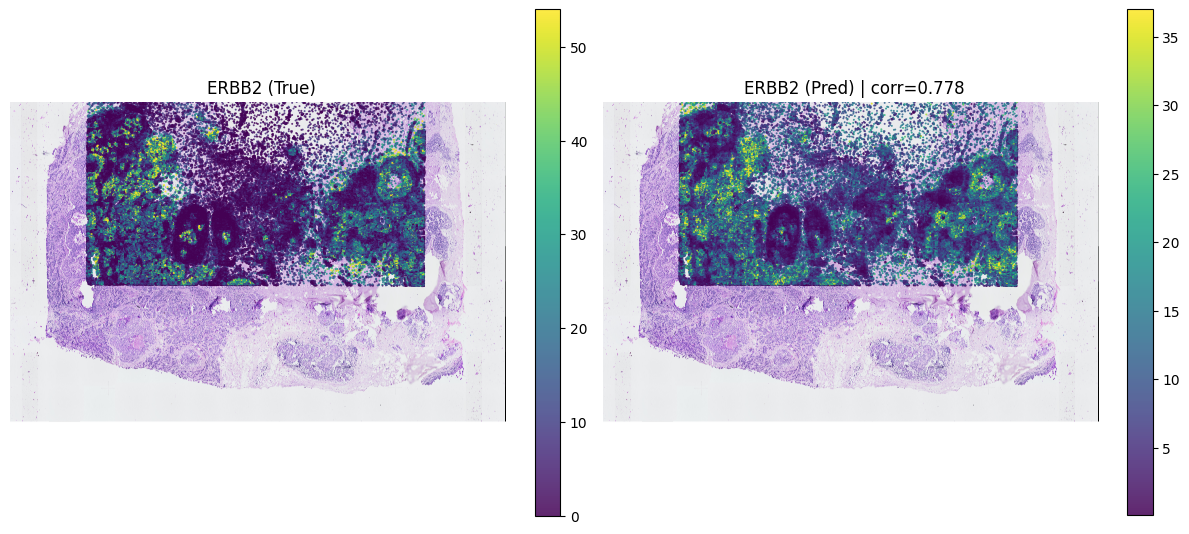

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

gene_name = "ERBB2"  # change to your gene of interest
gi = kept_genes.index(gene_name)
gt = true_spot[:, gi]
pr = pred_spot[:, gi]
corr = np.corrcoef(gt, pr)[0, 1]

coords = test_ds.locs_px
x = coords[:, 1]
y = coords[:, 0]

he_img = np.array(Image.open(ROOT / "data" / "superres_cache" / TEST_ID / "he.jpg"))


def robust_vmin_vmax(arr, p_low=1, p_high=99):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.percentile(a, [p_low, p_high])
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        vmin, vmax = float(np.min(a)), float(np.max(a))
        if vmin == vmax:
            eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
            vmin, vmax = vmin - eps, vmax + eps
    return vmin, vmax


vmin_gt, vmax_gt = robust_vmin_vmax(gt)
vmin_pr, vmax_pr = robust_vmin_vmax(pr)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]
ax.imshow(he_img)
sc0 = ax.scatter(x, y, c=gt, s=2, alpha=0.85, cmap="viridis", vmin=vmin_gt, vmax=vmax_gt, edgecolors="none")
ax.set_title(f"{gene_name} (True)")
ax.axis("off")
plt.colorbar(sc0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
ax.imshow(he_img)
sc1 = ax.scatter(x, y, c=pr, s=2, alpha=0.85, cmap="viridis", vmin=0.05, vmax=vmax_pr, edgecolors="none")
ax.set_title(f"{gene_name} (Pred) | corr={corr:.3f}")
ax.axis("off")
plt.colorbar(sc1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(RESULT_DIR / "spot_level_plot_ERBB2.pdf", bbox_inches="tight", dpi=300)
plt.show()


## 7. Super-resolution Prediction (Dense Map)
This predicts on the full embedding grid.
If `SUPERRES_GENES=None`, all genes are predicted; otherwise only selected genes.


In [9]:
if RUN_SUPERRES:
    from skimage.transform import resize
    from PIL import Image
    from numpy.lib.format import open_memmap

    cache_dir = ROOT / "data" / "superres_cache" / TEST_ID
    he_img = np.array(Image.open(cache_dir / "he.jpg"))

    try:
        tissue_mask = np.array(Image.open(cache_dir / "mask-small.png")) > 0
    except Exception:
        tissue_mask = None

    # Choose genes to predict
    if SUPERRES_GENES is None:
        superres_gene_names = list(kept_genes)
    else:
        superres_gene_names = list(SUPERRES_GENES)

    superres_gene_indices = [kept_genes.index(g) for g in superres_gene_names]
    sel_gene_ids_all = gene_ids[superres_gene_indices]

    H, W, C = embs_norm.shape
    print(f"Embeddings shape: {embs_norm.shape}")

    # Prepare tissue mask to match embedding grid
    if tissue_mask is not None and tissue_mask.shape != (H, W):
        tissue_mask = resize(tissue_mask.astype(float), (H, W), order=0, preserve_range=True) > 0.5

    finite_mask = np.isfinite(embs_norm).all(-1)
    if tissue_mask is not None:
        mask_all = finite_mask & tissue_mask
    else:
        mask_all = finite_mask

    pred_path = RESULT_DIR / "pred_superres.npy"
    gene_path = RESULT_DIR / "pred_superres_genes.json"

    # Decide whether to reuse cached super-res
    use_cache = False
    if REUSE_SUPERRES_CACHE and pred_path.exists() and gene_path.exists():
        existing_genes = json.loads(gene_path.read_text())
        try:
            existing_shape = np.load(pred_path, mmap_mode="r").shape
        except Exception:
            existing_shape = None

        if SUPERRES_GENES is None:
            if existing_genes == list(kept_genes) and existing_shape == (H, W, len(existing_genes)):
                use_cache = True
        else:
            if all(g in existing_genes for g in superres_gene_names) and existing_shape is not None and existing_shape[:2] == (H, W):
                use_cache = True

    if use_cache:
        print("Using cached super-res predictions:", pred_path)
    else:
        # Save gene list for downstream visualization
        gene_path.write_text(json.dumps(superres_gene_names, indent=2), encoding="utf-8")

        # Predict in gene chunks to avoid OOM
        superres_gene_chunk = 8  # adjust if GPU memory allows
        G = len(superres_gene_names)
        pred_maps = open_memmap(pred_path, mode="w+", dtype=np.float32, shape=(H, W, G))

        row_batch = 64
        gene_iter = range(0, G, superres_gene_chunk)
        gene_iter = tqdm(gene_iter, desc="Super-res genes", ncols=100) if tqdm else gene_iter

        with torch.no_grad():
            for g0 in gene_iter:
                g1 = min(G, g0 + superres_gene_chunk)
                sel_gene_ids = torch.tensor(sel_gene_ids_all[g0:g1], device=device, dtype=torch.long)

                row_iter = range(0, H, row_batch)
                row_iter = tqdm(row_iter, desc=f"Rows g{g0}:{g1}", ncols=100, leave=False) if tqdm else row_iter

                for y0 in row_iter:
                    y1 = min(H, y0 + row_batch)
                    x = torch.from_numpy(embs_norm[y0:y1]).to(device)
                    B, W_row, C = x.shape
                    x_flat = x.reshape(-1, C)
                    z = model.adapter(x_flat)
                    gene_ids_t = sel_gene_ids.unsqueeze(0).expand(x_flat.shape[0], -1)
                    cell_emb, gene_emb = model.cellfm(z, gene_ids_t)
                    y = model.cellfm.cellwise_decode(cell_emb, gene_emb)
                    y = torch.nn.functional.softplus(y)
                    y = y.view(B, W_row, g1 - g0)

                    y_np = y.cpu().numpy()
                    mask_row = mask_all[y0:y1]
                    y_np[~mask_row[..., None]] = np.nan
                    pred_maps[y0:y1, :, g0:g1] = y_np

        print("Saved super-res maps to", pred_path)


## 7.5 Spot-level from Super-resolution (Optional)
This step derives spot-level predictions from the dense super-res map,
then computes correlation against true spot counts and visualizes True vs Pred.


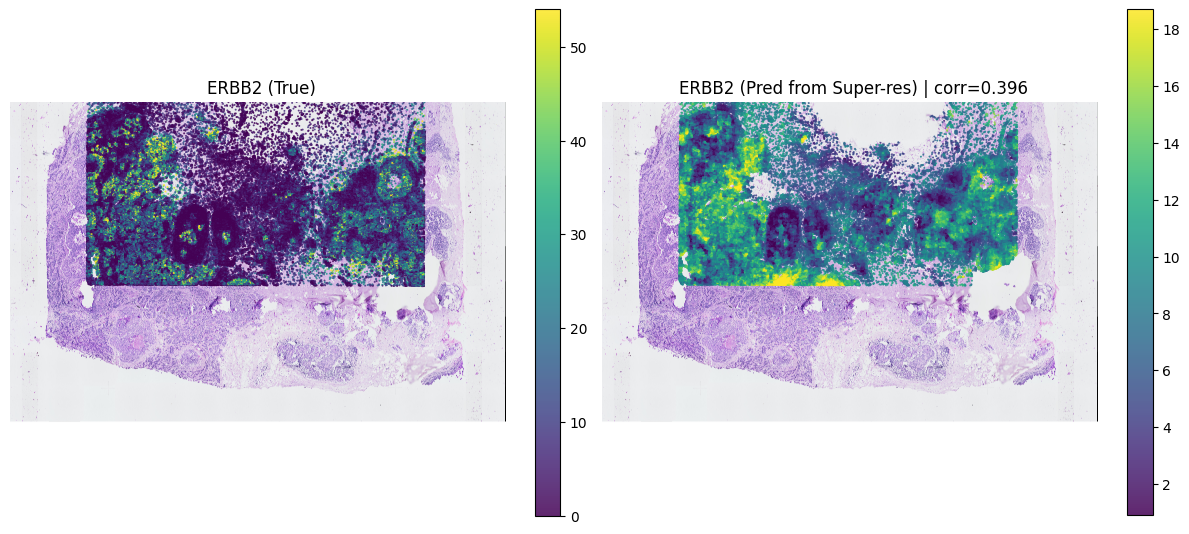

In [10]:
import json
from numpy.lib.format import open_memmap

if BUILD_SPOT_FROM_SUPERRES:
    pred_sr_path = RESULT_DIR / "pred_superres.npy"
    gene_list_path = RESULT_DIR / "pred_superres_genes.json"
    out_spot_path = RESULT_DIR / "pred_spot_from_superres.npy"
    out_corr_path = RESULT_DIR / "corr_spot_from_superres.npy"

    if REUSE_SPOT_FROM_SUPERRES_CACHE and out_spot_path.exists() and out_corr_path.exists():
        pred_spot_sr = np.load(out_spot_path)
        corr_spot_sr = np.load(out_corr_path)
        print("Using cached spot-from-superres outputs.")
    else:
        # Load super-res predictions (memmap) and gene list
        pred_maps = np.load(pred_sr_path, mmap_mode="r")
        gene_list = json.loads(gene_list_path.read_text())

        # Map super-res genes to true spot order
        gene_idx = [kept_genes.index(g) for g in gene_list]
        true_spot_sub = true_spot[:, gene_idx]

        # Build disk mask in embedding-grid space
        GRID_FACTOR = 16
        radius_grid = float(radius) / GRID_FACTOR

        def get_disk_mask(radius):
            radius_ceil = int(np.ceil(radius))
            locs = np.meshgrid(
                np.arange(-radius_ceil, radius_ceil + 1),
                np.arange(-radius_ceil, radius_ceil + 1),
                indexing="ij",
            )
            locs = np.stack(locs, axis=-1)
            distsq = (locs ** 2).sum(-1)
            return distsq <= radius ** 2

        mask = get_disk_mask(radius_grid)
        mh, mw = mask.shape
        cy, cx = mh // 2, mw // 2

        H, W, G = pred_maps.shape
        N = test_ds.locs_px.shape[0]
        pred_spot_sr = np.full((N, G), np.nan, dtype=np.float32)

        # Spot locations -> embedding grid coords (y, x)
        locs_grid = np.round(test_ds.locs_px / GRID_FACTOR).astype(np.int64)

        for i in range(N):
            y, x = locs_grid[i]
            y0, y1 = y - cy, y - cy + mh
            x0, x1 = x - cx, x - cx + mw
            if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
                continue
            patch = pred_maps[y0:y1, x0:x1, :]
            if mask.all():
                vals = patch.reshape(-1, G)
            else:
                vals = patch[mask]
            pred_spot_sr[i] = np.nanmean(vals, axis=0)

        # Correlations per gene
        corr_spot_sr = np.full(G, np.nan, dtype=np.float32)
        for gi in range(G):
            a = pred_spot_sr[:, gi]
            b = true_spot_sub[:, gi]
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 0:
                corr_spot_sr[gi] = np.corrcoef(a[m], b[m])[0, 1]

        np.save(out_spot_path, pred_spot_sr)
        np.save(out_corr_path, corr_spot_sr)
        print("Saved spot-from-superres predictions:", out_spot_path)
        print("Saved spot-from-superres correlations:", out_corr_path)

    # Visualization for a chosen gene
    gene_name = "ERBB2"  # change to your gene of interest
    gene_list = json.loads((RESULT_DIR / "pred_superres_genes.json").read_text())
    if gene_name not in gene_list:
        raise ValueError(f"{gene_name} not in pred_superres_genes.json")
    gi = gene_list.index(gene_name)

    # True vs Pred (from super-res)
    true_spot_sub = true_spot[:, [kept_genes.index(gene_name)]]
    gt = true_spot_sub[:, 0]
    pr = pred_spot_sr[:, gi]
    corr = np.corrcoef(gt[np.isfinite(pr)], pr[np.isfinite(pr)])[0, 1]

    # Plot
    import matplotlib.pyplot as plt
    from PIL import Image
    he_img = np.array(Image.open(ROOT / "data" / "superres_cache" / TEST_ID / "he.jpg"))
    coords = test_ds.locs_px
    x = coords[:, 1]
    y = coords[:, 0]

    def robust_vmin_vmax(arr, p_low=1, p_high=99):
        a = np.asarray(arr, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:
            return 0.0, 1.0
        vmin, vmax = np.percentile(a, [p_low, p_high])
        if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
            vmin, vmax = float(np.min(a)), float(np.max(a))
            if vmin == vmax:
                eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
                vmin, vmax = vmin - eps, vmax + eps
        return vmin, vmax

    vmin_gt, vmax_gt = robust_vmin_vmax(gt)
    vmin_pr, vmax_pr = robust_vmin_vmax(pr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax = axes[0]
    ax.imshow(he_img)
    sc0 = ax.scatter(x, y, c=gt, s=2, alpha=0.85, cmap="viridis", vmin=vmin_gt, vmax=vmax_gt, edgecolors="none")
    ax.set_title(f"{gene_name} (True)")
    ax.axis("off")
    plt.colorbar(sc0, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1]
    ax.imshow(he_img)
    sc1 = ax.scatter(x, y, c=pr, s=2, alpha=0.85, cmap="viridis", vmin=vmin_pr, vmax=vmax_pr, edgecolors="none")
    ax.set_title(f"{gene_name} (Pred from Super-res) | corr={corr:.3f}")
    ax.axis("off")
    plt.colorbar(sc1, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(RESULT_DIR / "superres_spot_ERBB2.pdf", bbox_inches="tight", dpi=300)
    plt.show()


## 8. Super-resolution Visualization
Super-resolution has no pixel-level ground truth; we visualize prediction only.


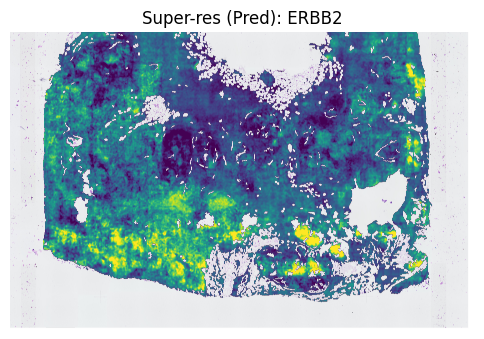

In [11]:
from skimage.transform import resize
from PIL import Image
import matplotlib.pyplot as plt
import json

gene_name = "ERBB2"  # change to your gene of interest

pred_maps = np.load(RESULT_DIR / "pred_superres.npy")
gene_list = json.loads((RESULT_DIR / "pred_superres_genes.json").read_text())

if gene_name not in gene_list:
    raise ValueError(f"{gene_name} not in pred_superres_genes.json. Available: {gene_list[:10]}...")
gi = gene_list.index(gene_name)

pm = pred_maps[..., gi]
he_img = np.array(Image.open(ROOT / "data" / "superres_cache" / TEST_ID / "he.jpg"))

if pm.shape != he_img.shape[:2]:
    pm = resize(pm, he_img.shape[:2], order=1, preserve_range=True, anti_aliasing=False).astype(np.float32)

vmin, vmax = np.nanpercentile(pm, [1, 99])

plt.figure(figsize=(6, 6))
plt.imshow(he_img)
plt.imshow(pm, cmap="viridis", alpha=1, vmin=vmin, vmax=vmax)
plt.title(f"Super-res (Pred): {gene_name}")
plt.axis("off")
plt.savefig(RESULT_DIR / "superres_all.pdf", bbox_inches="tight", dpi=300)
plt.show()

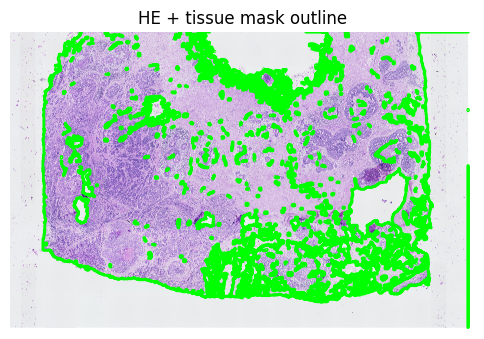

In [12]:
# ----------------------------
# Visualize tissue_mask with outline
# ----------------------------
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Step 1) Read HE and tissue mask
cache_dir = ROOT / "data" / "superres_cache" / TEST_ID
he_img = np.array(Image.open(cache_dir / "he.jpg"))
mask_small = np.array(Image.open(cache_dir / "mask-small.png")) > 0

# Step 2) Upsample mask to HE size
mask_up = Image.fromarray((mask_small * 255).astype(np.uint8)).resize(
    (he_img.shape[1], he_img.shape[0]), resample=Image.NEAREST
)
mask_up = np.array(mask_up) > 0

# Step 3) Show outline on HE
plt.figure(figsize=(6, 6))
plt.imshow(he_img)
plt.contour(mask_up, levels=[0.5], colors="lime", linewidths=2)  # outline
plt.title("HE + tissue mask outline")
plt.axis("off")
plt.show()


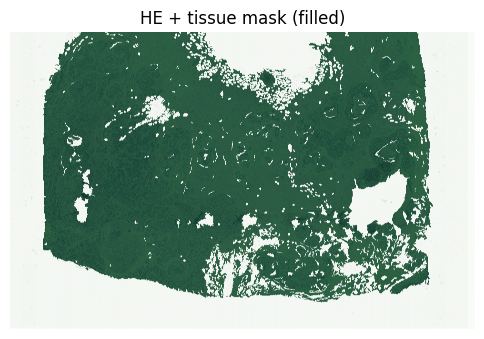

In [13]:
plt.figure(figsize=(6, 6))
plt.imshow(he_img)
plt.imshow(mask_up, cmap="Greens", alpha=0.8)  # 填充区域
plt.title("HE + tissue mask (filled)")
plt.axis("off")
plt.show()


---
### Output Summary
- `pred_spot.npy` / `true_spot.npy`
- `gene_corrs.npy`
- `gene_gene_corr_pred.npy` / `gene_gene_corr_true.npy` / `gene_gene_corr_delta.npy` (optional)
- `pred_superres.npy` (optional)

You can proceed with downstream analyses from here.
